# Demand Predict

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import glob
import os

folder_path = "/content/drive/MyDrive/datadbkomp/"

# Corrected: Use a pattern to match all .xlsx files in the folder
files = glob.glob(os.path.join(folder_path, "*.xlsx"))

all_data = []

# Check if files list is empty before proceeding
if not files:
    print(f"No .xlsx files found in {folder_path}")
else:
    for file in files:
        df = pd.read_excel(file)

        # ambil nama file sebagai nama perusahaan
        perusahaan = os.path.basename(file).replace(".xlsx","")

        df["Perusahaan"] = perusahaan

        all_data.append(df)

    df_all = pd.concat(
        all_data,
        ignore_index=True
    )

    print(df_all.shape)

    df_all.head()

(106814, 21)


In [3]:
print(df_all["Perusahaan"].value_counts().head(30))

Perusahaan
ENTER KOMPUTER        13826
BLESSING COMPUTER     12037
STARCOMP               9635
DBKLIK                 8095
SURYA MITRA ONLINE     7827
JAYAPC                 7642
EXPERT KOMPUTER        7375
MULTIFUNGSI            4991
YOUNGS COMPUTER        4862
GEGESTORE              4545
ITSHOP                 4103
TECH ISLAND            3674
NANO COMPUTER          3456
PLANET COMPUTER        3354
ONE IT                 3093
IMPC                   3026
ABDITAMA               2688
LEVEL99                2490
MOLONG                   95
Name: count, dtype: int64


In [4]:
df_all.columns.tolist()

['Datetime',
 'Nama Produk',
 'Harga',
 'Qty',
 'Omset (bln)',
 'Qty (mg)',
 'Omset (mg)',
 'Perusahaan',
 'clean_name',
 'SKU',
 'Kategori',
 'Nama Accurate',
 'Stock Total',
 'HPP (Latest)',
 'Shopee',
 'Kategori Shopee',
 'Margin Harga Shopee (Nilai)',
 'Margin Persen Shopee (%)',
 'SKU_BASE',
 'Margin',
 'Margin_Pct']

In [5]:
df_all[df_all["Perusahaan"] == "DBKLIK"].head()

,Datetime,Nama Produk,Harga,Qty,Omset (bln),Qty (mg),Omset (mg),Perusahaan,clean_name,SKU,...,Nama Accurate,Stock Total,HPP (Latest),Shopee,Kategori Shopee,Margin Harga Shopee (Nilai),Margin Persen Shopee (%),SKU_BASE,Margin,Margin_Pct
98719,2026-05-12 00:00:00,Headset Gaming NYK Nemesis BEAST PRO W60 7.1 T...,421000.0,1,421000.0,0.0,105250.0,DBKLIK,HEADSET GAMING NYK NEMESIS BEAST PRO W60 7 1 T...,AHSGNY0005,...,Headset Gaming NYK NEMESIS BEAST PRO W60 7.1 W...,6.0,325000.0,440000.0,"Kategori 7,20%",28760.0,0.088,AHSGNY0005,96000.0,22.802850
98720,2026-05-12 00:00:00,Ugreen Kabel Converter Display Port To Hdtv 2M...,151000.0,3,453000.0,0.0,113250.0,DBKLIK,UGREEN KABEL CONVERTER DISPLAY PORT TO HDTV 2M...,ACCUG0235-BC,...,Kabel UGreen DP to HDMI 2M - Black (10202),NaN,99000.0,158000.0,"Kategori 7,70%",27242.0,0.275,ACCUG0235,52000.0,34.437086
98721,2026-05-12 00:00:00,Aula Casing Pc Gaming Fz009 Atx Include 3 Fan ...,444000.0,1,444000.0,0.0,111000.0,DBKLIK,AULA CASING PC GAMING FZ009 ATX INCLUDE 3 FAN ...,CPAU0002,...,CASING PC AULA FZ009,12.0,350000.0,464000.0,"Kategori 4,20%",46256.0,0.132,CPAU0002,94000.0,21.171171
98722,2026-05-12 00:00:00,UGreen Wireless Bluetooth 2in1 Transmitter & R...,218000.0,2,436000.0,0.0,109000.0,DBKLIK,UGREEN WIRELESS BLUETOOTH 2IN1 TRANSMITTER REC...,ACCUG0425,...,Wireless Bluetooth UGreen 2in1 Transmitter & R...,4.0,150000.0,228000.0,"Kategori 10,20%",26472.0,0.176,ACCUG0425,68000.0,31.192661
98723,2026-05-12 00:00:00,Kabel UGreen 2 in 1 Dual USB-C Nylon Braided,218000.0,2,436000.0,0.0,109000.0,DBKLIK,KABEL UGREEN 2 IN 1 DUAL USB C NYLON BRAIDED,ACCUG0409-BC,...,Kabel UGreen 2 In 1 Type-C To Dual-C 100W Nylo...,14.0,155000.0,228000.0,"Kategori 10,20%",21472.0,0.139,ACCUG0409,63000.0,28.899083


In [6]:
df_all[
    df_all["Perusahaan"].str.contains(
        "DBKLIK",
        case=False,
        na=False
    )
].shape

(8095, 21)

In [7]:
df_db = df_all[df_all["Perusahaan"] == "DBKLIK"].copy()

print(df_db.shape)

print(df_db.columns.tolist())

(8095, 21)
['Datetime', 'Nama Produk', 'Harga', 'Qty', 'Omset (bln)', 'Qty (mg)', 'Omset (mg)', 'Perusahaan', 'clean_name', 'SKU', 'Kategori', 'Nama Accurate', 'Stock Total', 'HPP (Latest)', 'Shopee', 'Kategori Shopee', 'Margin Harga Shopee (Nilai)', 'Margin Persen Shopee (%)', 'SKU_BASE', 'Margin', 'Margin_Pct']


In [8]:
print("HPP NaN:",df_db["HPP (Latest)"].isna().sum())

print("HPP = 1:",(df_db["HPP (Latest)"] == 1).sum())

HPP NaN: 0
HPP = 1: 0


In [9]:
df_all["Harga"] = (
    df_all["Harga"]
    .astype(str)
    .str.replace("Rp","")
    .str.replace(".","")
    .str.replace(",","")
    .str.strip()
)

df_all["Harga"] = pd.to_numeric(
    df_all["Harga"],
    errors="coerce"
)

In [10]:
df_all["Qty"] = pd.to_numeric(
    df_all["Qty"],
    errors="coerce"
)

In [11]:
df_all["Datetime"] = pd.to_datetime(
    df_all["Datetime"],
    errors="coerce"
)

In [12]:
df_all = df_all.dropna(
    subset=[
        "Nama Produk",
        "Harga",
        "Qty"
    ]
)

df_all.shape

(106759, 21)

In [13]:
#cek banyak data yang kosong
df_all[
    ["Nama Produk","Harga","Qty"]
].isnull().sum()

,0
Nama Produk,0
Harga,0
Qty,0


In [14]:
df_all.groupby("Perusahaan")["Qty"].apply(
    lambda x: x.isna().sum()
).sort_values(ascending=False)

,Qty
Perusahaan,
ABDITAMA,0
BLESSING COMPUTER,0
DBKLIK,0
ENTER KOMPUTER,0
EXPERT KOMPUTER,0
GEGESTORE,0
IMPC,0
ITSHOP,0
JAYAPC,0


In [15]:
import re

def clean_text(text):

    text = str(text).upper()

    text = re.sub(r'[^A-Z0-9 ]', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

df_all["clean_name"] = (
    df_all["Nama Produk"]
    .apply(clean_text)
)

df_all.head()

,Datetime,Nama Produk,Harga,Qty,Omset (bln),Qty (mg),Omset (mg),Perusahaan,clean_name,SKU,...,Nama Accurate,Stock Total,HPP (Latest),Shopee,Kategori Shopee,Margin Harga Shopee (Nilai),Margin Persen Shopee (%),SKU_BASE,Margin,Margin_Pct
0,2026-04-15,FlashDisk Kingston DT70 128GB - DataTraveler 7...,2080000.0,850.0,176800000.0,212.0,44096000.0,JAYAPC,FLASHDISK KINGSTON DT70 128GB DATATRAVELER 70 ...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-04-15,FlashDisk Lexar OTG Jumpdrive D400 128GB - Fla...,3070000.0,555.0,170385000.0,138.0,42366000.0,JAYAPC,FLASHDISK LEXAR OTG JUMPDRIVE D400 128GB FLASH...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-04-15,VGA MSI GeForce RTX 4060 Ventus 2X Black OC 8G...,63500000.0,26.0,165100000.0,6.0,38100000.0,JAYAPC,VGA MSI GEFORCE RTX 4060 VENTUS 2X BLACK OC 8G...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-04-15,Kingston SSD NV3 M.2 Pcie Gen4 Nvme 1TB - M2 1 TB,29000000.0,31.0,89900000.0,7.0,20300000.0,JAYAPC,KINGSTON SSD NV3 M 2 PCIE GEN4 NVME 1TB M2 1 TB,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-04-15,Kingston SSD KC3000 M.2 Pcie Gen4 Nvme 512GB -...,38990000.0,23.0,89677000.0,5.0,19495000.0,JAYAPC,KINGSTON SSD KC3000 M 2 PCIE GEN4 NVME 512GB M...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# =========================
# LOAD KAMUS BRAND
# =========================

kamus_brand = pd.read_excel(
    "kamusbrand.xlsx"
)

# rapikan jadi uppercase
kamus_brand["Alias"] = (
    kamus_brand["Alias"]
    .astype(str)
    .str.upper()
)

kamus_brand["Brand_Utama"] = (
    kamus_brand["Brand_Utama"]
    .astype(str)
    .str.upper()
)

# buat dictionary
brand_dict = dict(
    zip(
        kamus_brand["Alias"],
        kamus_brand["Brand_Utama"]
    )
)

# =========================
# FUNCTION EXTRACT BRAND
# =========================

def extract_brand(text):

    text = str(text).upper()

    for Alias, brand in brand_dict.items():

        if Alias in text:
            return brand

    return "UNKNOWN"

# =========================
# APPLY KE DATA
# =========================

df_all["Brand"] = (
    df_all["clean_name"]
    .apply(extract_brand)
)

# cek hasil
df_all[
    ["Nama Produk", "Brand"]
].head(20)

,Nama Produk,Brand
0,FlashDisk Kingston DT70 128GB - DataTraveler 7...,KINGSTON
1,FlashDisk Lexar OTG Jumpdrive D400 128GB - Fla...,LEXAR
2,VGA MSI GeForce RTX 4060 Ventus 2X Black OC 8G...,MSI
3,Kingston SSD NV3 M.2 Pcie Gen4 Nvme 1TB - M2 1 TB,KINGSTON
4,Kingston SSD KC3000 M.2 Pcie Gen4 Nvme 512GB -...,KINGSTON
5,MSI MAG A650BN 650W PSU - Power Supply 650 Wat...,MSI
6,"WD Blue SA510 SSD 500GB Sata 3 - 500 GB 2.5""",WD
7,FlashDisk Lexar OTG Jumpdrive D400 64GB - Flas...,LEXAR
8,VGA Asus Dual GeForce RTX 5060 OC 8GB - 8 GB G...,ASUS
9,WD Black SSD SN850X M.2 Pcie Gen4 Nvme 2280 1T...,WD


EDA AWAL

In [17]:
import matplotlib.pyplot as plt

produk_unik = (
    df_all
    .groupby("Perusahaan")["Nama Produk"]
    .nunique()
    .sort_values(ascending=False)
)

produk_unik

,Nama Produk
Perusahaan,
ENTER KOMPUTER,4909
BLESSING COMPUTER,4502
DBKLIK,4355
STARCOMP,3432
PLANET COMPUTER,2761
ITSHOP,2424
SURYA MITRA ONLINE,2380
EXPERT KOMPUTER,2127
JAYAPC,1971


In [18]:
brand_count = (
    df_all["Brand"]
    .value_counts()
    .head(25)
)

brand_count

,count
Brand,
UNKNOWN,6517
AMD,4824
GREE,4725
REXUS,4057
VENTION,3843
LOGITECH,3629
MSI,3616
ASUS,3272
FANTECH,2738


memperbaiki produk dengan brand unknown

In [19]:
unknown = df_all[
    df_all["Brand"] == "UNKNOWN"
]

print("Jumlah UNKNOWN :", len(unknown))

Jumlah UNKNOWN : 6517


In [20]:
unknown["Nama Produk"].sample(20)

,Nama Produk
69138,LIAN LI PC Casing Lancool 217 INF BLACK
75931,CUBE GAMING BREEZE Single White CPU Cooler - S...
86344,CUBE GAMING KNOMA BLACK - ATX Gaming Case - Te...
48499,Lian Li Uni Fan TL 140 Wireless | ARGB Fan Cas...
76671,PC Rakitan EK Gaming BattleStar Lite 506 - Cor...
81078,Kabel LAN 2 Meter - Standard
78760,Lamzu Maya 4K Ultralight Ergonomic Wireless Ga...
79827,CUBE GAMING QUITOZ BLACK - mATX Gaming Case - ...
76320,PC Rakitan EK Gaming BattleXtream A3 - Ryzen 5...
22999,Kabel MHL Converter Micro USB Male to HDMI Male


In [21]:
from collections import Counter

all_words = " ".join(
    unknown["Nama Produk"]
    .astype(str)
    .str.upper()
)

words = all_words.split()

counter = Counter(words)

pd.DataFrame(
    counter.most_common(100),
    columns=["Kata", "Frekuensi"]
)

,Kata,Frekuensi
0,-,4447
1,GAMING,2129
2,PC,1259
3,/,1047
4,WHITE,950
...,...,...
95,MESH,142
96,128GB,141
97,STANDARD,139
98,INCLUDE,139


In [22]:
stopwords = {

    "MONITOR","CASING","FAN","/","PC","BLACK","WHITE","CASE","I","ARGB","COOLER","WITH","RAKITAN","ATX","PWM", "PSU","GAMING","LED","SSD",
    "DDR4","DDR5","RAM","INCH","GB","TB","PC","CPU","VGA","WIFI","WIRELESS","USB","KABEL","I","-","|","PRO","CUBE","CPU","THERMAL","16GB","8GB","KOMPUTER","GLASS","TO","3","POWER","PACK","MODULAR","TEMPERED",
    "LIQUID","SINGLE","12CM","+","WIRELESS","DUAL","RGB","LCD","A-RGB","SIDE","&","OC","III","PERFORMANCE","CORE","KEYBOARD","GARANSI","WATT","FULLY","3.1","120","120MM","SATA","5060","MINI","PST","SUPPLY",
    "360","RX","RESMI","PREMIUM","PCIE","NVME","AIO","SCREEN","MATX","HDMI","TI","TOWER","GDDR7","M-ATX","MOUSE","FRONT","P12","2","CASING","LIAN","LI","ENTER", "EK", "CARD", "REQ", "DESIGN", "80+",
     "5", "RYZEN", "5", "BLUETOOTH", "TYPE-C"}

words = []

for nama in unknown["Nama Produk"]:

    for kata in str(nama).upper().split():

        if kata not in stopwords:

            words.append(kata)

counter = Counter(words)

pd.DataFrame(counter.most_common(100),columns=["Kata","Frekuensi"])

,Kata,Frekuensi
0,GOLD,349
1,RTX,213
2,CABLE,196
3,LEFT,193
4,32GB,190
...,...,...
95,BLUE,76
96,ATX3.1,76
97,MEMORY,74
98,CHARGER,72


In [23]:
unknown_db = df_all[

    (df_all["Brand"] == "UNKNOWN")
    &
    (df_all["Perusahaan"] == "DBKLIK")

]

print("Jumlah UNKNOWN DBKlik :", len(unknown_db))

Jumlah UNKNOWN DBKlik : 24


In [24]:
unknown_db[["Nama Produk"]].sample(20)

,Nama Produk
106001,Video Recorder VIGI NVR4032H 32 Chanel
99569,No Brand Kabel Adapter Audio 1 Male To 2 Femal...
105831,Thermal Grease ID Cooling Frost X35 4gram
104592,Kabel Power Server
106093,Cashdrawer Iware 408
106343,Memory RAM ECC DDR4 16GB 3200MHz
101264,No Brand Kabel Adapter Audio 1 Male To 2 Femal...
104446,Goodie Bag Ukuran 37x30x9
106485,CPU Liquid Cooler TRYX Panorama SE 360 ARGB - ...
105239,Router Mi AC1200 EU Dual Band Gigabit Wifi 5


In [25]:
# =========================
# SPLIT DBKLIK & KOMPETITOR
# =========================

df_db = df_all[
    df_all["Perusahaan"] == "DBKLIK"
].copy()

df_komp = df_all[
    df_all["Perusahaan"] != "DBKLIK"
].copy()

print("DBKLIK :", df_db.shape)
print("KOMPETITOR :", df_komp.shape)

DBKLIK : (8095, 22)
KOMPETITOR : (98664, 22)


# match with code model

In [26]:
df_db[["Nama Produk","clean_name","Brand"]].sample(20)

,Nama Produk,clean_name,Brand
106660,Screen Protector UGreen Magnetic MacBook 14.2 ...,SCREEN PROTECTOR UGREEN MAGNETIC MACBOOK 14 2 ...,APPLE
103787,"Ugreen Kabel Audio Aux 3,5Mm Male To 2 Rca Mal...",UGREEN KABEL AUDIO AUX 3 5MM MALE TO 2 RCA MAL...,GREE
103222,Xiaomi Vacuum Cleaner Robot E5 2000Pa 2600Mah,XIAOMI VACUUM CLEANER ROBOT E5 2000PA 2600MAH,ROBOT
104205,PC AIO MSI PRO AP241 11M-441ID / INTEL Core i5...,PC AIO MSI PRO AP241 11M 441ID INTEL CORE I5 1...,THERMAFROST
103444,Sandisk Flashdisk Ultra Flair 16Gb Cz73 Usb 3....,SANDISK FLASHDISK ULTRA FLAIR 16GB CZ73 USB 3 ...,SANDISK
103090,Keyboard Gaming Mechanical NYK NEMESIS LOKI MK...,KEYBOARD GAMING MECHANICAL NYK NEMESIS LOKI MK...,NEMESIS
105568,TWS SONY LINKBUDS/H WF-L900 - Grey/Black,TWS SONY LINKBUDS H WF L900 GREY BLACK,SONY
100537,Asus Notebook B1400Ceae-Ek3424Ts I3-1115G4 4Gb...,ASUS NOTEBOOK B1400CEAE EK3424TS I3 1115G4 4GB...,ASUS
99703,Ugreen Kabel Usb-A 2.0 To Usb-C 50Cm Nylon - B...,UGREEN KABEL USB A 2 0 TO USB C 50CM NYLON BLA...,GREE
101008,Xiaomi Koper Luggage Classic Pro 26 inch - Black,XIAOMI KOPER LUGGAGE CLASSIC PRO 26 INCH BLACK,XIAOMI


In [27]:
import re

def extract_main_model(text):

    text = str(text).upper()

    kandidat = re.findall(
        r'\b[A-Z0-9-]{4,}\b',
        text
    )

    blacklist = {
        # RAM & Storage
        '2GB','3GB','4GB','6GB','8GB','12GB','16GB','18GB','24GB',
        '32GB','48GB','64GB','96GB',
        '128GB','256GB','512GB',
        '1TB','2TB','4TB','8TB',

        # RAM Type
        'DDR3','DDR4','DDR5','DDR5X','DDR6','LPDDR4','LPDDR4X','LPDDR5','LPDDR5X',

        # Refresh Rate
        '60HZ','75HZ','90HZ','100HZ','120HZ','144HZ','165HZ',
        '170HZ','180HZ','200HZ','240HZ','300HZ','360HZ',

        # Internet / Network Speed
        '10MBPS','54MBPS','100MBPS','150MBPS','300MBPS',
        '433MBPS','600MBPS','867MBPS','1000MBPS','1200MBPS',
        '1800MBPS','2400MBPS','3000MBPS','5400MBPS',
        '1GBPS','2.5GBPS','5GBPS','10GBPS','20GBPS','30GBPS', '100MB',

        # Resolution
        '720P','1080P','1440P','2K','4K','5K','8K',
        'HD','HD+','FHD','FULLHD','FULL','FULL-HD',
        'QHD','UHD','WQHD',

        # Operating System
        'DOS','NOOS','WINDOWS','WINDOWS10','WINDOWS11',
        'WIN10','WIN11','W10','W11',

        # Charger / PSU
        '45W','65W','90W','120W','140W','180W', '100W','165W','200W','250W,','300W','350W','400W','450W',
        '240W','330W','480W','550W','650W','750W','850W',

        # Display Size (opsional)
        '13INCH','13.3INCH','14INCH','15.6INCH','16INCH',
        '17INCH','18INCH',

        # Warna
        'BLACK','WHITE','SILVER','GREY','GRAY',
        'BLUE','RED','GREEN','PINK','GOLD',
        'TITANIUM','PURPLE',

        # Kondisi / Promosi
        'NEW','BNIB','SEGEL','ORI','ORIGINAL',
        'OFFICIAL','OFFICIALSTORE','OFFICIALSHOP',
        'GARANSI','RESMI','READY','READYSTOCK',
        'PROMO','DISKON','BONUS','FREE','COD', '2IN1',

        # Kata umum yang tidak membantu matching
        'LAPTOP','NOTEBOOK','PC','KOMPUTER',
        'SMARTPHONE','HP','HANDPHONE','TABLET', 'RJ45',

        # GEN
        'GEN1','GEN2','GEN3','GEN4','GEN5','GEN6','GEN7','GEN8','GEN9','GEN10',
    }

    kandidat = [
        x for x in kandidat
        if (
            re.search('[A-Z]', x)
            and
            re.search('[0-9]', x)
            and
            x not in blacklist
        )
    ]

    if len(kandidat) == 0:
        return None

    # ambil kandidat terpanjang
    return max(kandidat, key=len)

df_all["Main_Model"] = (
    df_all["clean_name"]
    .apply(extract_main_model)
)

In [28]:
df_all[["Nama Produk", "Main_Model"]].sample(20)

,Nama Produk,Main_Model
35443,UGREEN X516 Charger 30W GaN N Series Mini 2 Po...,X516
25330,HP 14 EP1177TU Core 5 120U Core 5 120U 8GB 512...,EP1177TU
30710,Anker Soundcore AeroFit 2 V20i OWS Hi-Res Wire...,V20I
15744,Kingston FURY BEAST DDR4 16GB (2x8GB) 3200MHz,3200MHZ
61077,Fantech RHASTA G10 Pro-Gaming Mouse Wired,None
86964,Mouse Gaming Razer DeathAdder Essential Black ...,None
69175,FINGERSPOT VIVO W-2421M mesin absensi wajah ac...,2421M
42466,Adaptor Laptop HP 19.5V 3.33A 65W DC 4.5*3.0 m...,None
1601,Asus Mini Pc NUC Pro 14 NUC14RVHU7 Kit Barebon...,NUC14RVHU7
66052,Printer EPSON L3211 (Print Scan Copy + Ink Tank),L3211


In [29]:
df_all["Main_Model"].notna().mean() * 100

np.float64(66.46840079056567)

In [30]:
df_db = df_all[df_all["Perusahaan"]=="DBKLIK"]

df_komp = df_all[df_all["Perusahaan"]!="DBKLIK"]

df_db["Main_Model"]
df_komp["Main_Model"]

,Main_Model
0,DT70
1,D400
2,None
3,None
4,KC3000
...,...
98714,I7KANTOR
98715,BK8000
98716,512GSSD
98717,N150


In [31]:
import re

def extract_specs(text):

    text = str(text).upper()

    specs = []

    # Storage
    specs += re.findall(r'\b\d+TB\b', text)
    specs += re.findall(r'\b\d+GB\b', text)

    # RAM Type
    specs += re.findall(r'\bDDR[3456X]*\b', text)

    # Refresh Rate
    specs += re.findall(r'\b\d+HZ\b', text)

    return "|".join(sorted(set(specs)))

df_all["Specs"] = df_all["clean_name"].apply(extract_specs)

In [32]:
df_db = df_all[df_all["Perusahaan"] == "DBKLIK"].copy()

df_komp = df_all[df_all["Perusahaan"] != "DBKLIK"].copy()

In [33]:
import pandas as pd

matches_model = []

for _, row_db in df_db.iterrows():

    brand_db = row_db["Brand"]
    model_db = row_db["Main_Model"]
    specs_db = row_db["Specs"]

    if pd.isna(model_db):
        continue

    kandidat = df_komp[
        (df_komp["Brand"] == brand_db)
        &
        (df_komp["Main_Model"] == model_db)
    ]

    if len(kandidat) == 0:
        continue

    # Kalau DB punya spesifikasi
    if specs_db != "":

        kandidat = kandidat[
            kandidat["Specs"] == specs_db
        ]

    if len(kandidat) == 0:
        continue

    for _, row_komp in kandidat.iterrows():

        matches_model.append({

            "Datetime_DB": row_db["Datetime"],
            "Nama_DB": row_db["Nama Produk"],
            "Harga_DB": row_db["Harga"],
            "Qty_DB": row_db["Qty"],
            "Omset_DB": row_db["Omset (bln)"],
            "Brand_DB": row_db["Brand"],
            "Main_Model_DB": row_db["Main_Model"],
            "Specs_DB": row_db["Specs"],

            "Perusahaan_Komp": row_komp["Perusahaan"],
            "Datetime_Komp": row_komp["Datetime"],
            "Nama_Komp": row_komp["Nama Produk"],
            "Harga_Komp": row_komp["Harga"],
            "Qty_Komp": row_komp["Qty"],
            "Omset_Komp": row_komp["Omset (bln)"],
            "Brand_Komp": row_komp["Brand"],
            "Main_Model_Komp": row_komp["Main_Model"],
            "Specs_Komp": row_komp["Specs"],

            "Similarity": 1.0,
            "Method": "MODEL_CODE"
        })

df_match_model = pd.DataFrame(matches_model)

print(df_match_model.shape)

(55249, 19)


In [34]:
print("Produk match model:",df_match_model["Nama_DB"].nunique())

print("Coverage:",round(df_match_model["Nama_DB"].nunique()/df_db["Nama Produk"].nunique()* 100,2),"%")

Produk match model: 1349
Coverage: 30.98 %


In [35]:
df_match_model.head()

,Datetime_DB,Nama_DB,Harga_DB,Qty_DB,Omset_DB,Brand_DB,Main_Model_DB,Specs_DB,Perusahaan_Komp,Datetime_Komp,Nama_Komp,Harga_Komp,Qty_Komp,Omset_Komp,Brand_Komp,Main_Model_Komp,Specs_Komp,Similarity,Method
0,2026-05-12,Sandisk Micro Sd Max Endurance Sdhc 32Gb 100Mb...,2120000.0,2.0,424000.0,SANDISK,GN6IA,32GB,LEVEL99,2026-04-15,Sandisk High Endurance MicroSD Card 32GB Memor...,3900000.0,8.0,3120000.0,SANDISK,GN6IA,32GB,1.0,MODEL_CODE
1,2026-05-12,Sandisk Micro Sd Max Endurance Sdhc 32Gb 100Mb...,2120000.0,2.0,424000.0,SANDISK,GN6IA,32GB,LEVEL99,2026-04-15,SanDisk Max Endurance MicroSD 32GB Class 10 V3...,6100000.0,2.0,1220000.0,SANDISK,GN6IA,32GB,1.0,MODEL_CODE
2,2026-05-12,Sandisk Micro Sd Max Endurance Sdhc 32Gb 100Mb...,2120000.0,2.0,424000.0,SANDISK,GN6IA,32GB,LEVEL99,2026-04-21,Sandisk High Endurance MicroSD Card 32GB Memor...,3900000.0,8.0,3120000.0,SANDISK,GN6IA,32GB,1.0,MODEL_CODE
3,2026-05-12,Sandisk Micro Sd Max Endurance Sdhc 32Gb 100Mb...,2120000.0,2.0,424000.0,SANDISK,GN6IA,32GB,LEVEL99,2026-04-28,Sandisk High Endurance MicroSD Card 32GB Memor...,4100000.0,7.0,2870000.0,SANDISK,GN6IA,32GB,1.0,MODEL_CODE
4,2026-05-12,Sandisk Micro Sd Max Endurance Sdhc 32Gb 100Mb...,2120000.0,2.0,424000.0,SANDISK,GN6IA,32GB,LEVEL99,2026-04-28,SanDisk Max Endurance MicroSD 32GB Class 10 V3...,6100000.0,1.0,610000.0,SANDISK,GN6IA,32GB,1.0,MODEL_CODE


In [36]:
matched_db = set(df_match_model["Nama_DB"])

df_db_sisa = df_db[~df_db["Nama Produk"].isin(matched_db)].copy()

print(df_db_sisa.shape)

(5436, 24)


In [37]:
df_match_model.shape

df_match_model["Nama_DB"].nunique()

1349

# TFIDF + NGRAM

In [38]:
# =========================
# TF-IDF + NGRAM
# =========================

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(

    ngram_range=(1,2),
    min_df=2
)

# fit ke seluruh nama produk
vectorizer.fit(
    df_all["clean_name"]
)

# ubah text jadi vector
tfidf_db = vectorizer.transform(df_db_sisa["clean_name"])

tfidf_komp = vectorizer.transform(df_komp["clean_name"])

print(tfidf_db.shape)
print(tfidf_komp.shape)

(5436, 99362)
(98664, 99362)


In [39]:
# =========================
# COSINE SIMILARITY MATCHING
# =========================

from sklearn.metrics.pairwise import cosine_similarity

matches = []

# loop semua produk DBKlik
for i in range(len(df_db_sisa)):

    row_db = df_db_sisa.iloc[i]

    # ambil brand produk DB
    brand_db = row_db["Brand"]

    # skip UNKNOWN
    if brand_db == "UNKNOWN":
        continue

    # ambil kompetitor dengan brand sama
    kandidat = df_komp[
        df_komp["Brand"] == brand_db
    ]

    # skip kalau kosong
    if len(kandidat) == 0:
        continue

    # vector produk DB
    vec_db = tfidf_db[i]

    # vector kandidat kompetitor
    vec_komp = vectorizer.transform(
        kandidat["clean_name"]
    )

    # hitung similarity
    sim_scores = cosine_similarity(
        vec_db,
        vec_komp
    )[0]

    # ambil TOP 5 similarity tertinggi
    top_idx = sim_scores.argsort()[-5:][::-1]

    for idx in top_idx:

        score = sim_scores[idx]

        # threshold similarity
        if score >= 0.60:

            row_komp = kandidat.iloc[idx]

            matches.append({

                # =====================
                # DBKLIK
                # =====================

                "Datetime_DB":
                    row_db["Datetime"],

                "Nama_DB":
                    row_db["Nama Produk"],

                "Harga_DB":
                    row_db["Harga"],

                "Qty_DB":
                    row_db["Qty"],

                "Omset_DB":
                    row_db["Omset (bln)"],

                "Brand_DB":
                    row_db["Brand"],

                # =====================
                # KOMPETITOR
                # =====================

                "Perusahaan_Komp":
                    row_komp["Perusahaan"],

                "Datetime_Komp":
                    row_komp["Datetime"],

                "Nama_Komp":
                    row_komp["Nama Produk"],

                "Harga_Komp":
                    row_komp["Harga"],

                "Qty_Komp":
                    row_komp["Qty"],

                "Omset_Komp":
                    row_komp["Omset (bln)"],

                "Brand_Komp":
                    row_komp["Brand"],

                # =====================
                # MATCHING SCORE
                # =====================

                "Similarity":
                    score
            })

# dataframe hasil matching
df_match_tfidf = pd.DataFrame(matches)

# urutkan dari similarity terbesar
df_match_tfidf = df_match_tfidf.sort_values(
    by="Similarity",
    ascending=False
)

print("Jumlah match:", df_match_tfidf.shape)

df_match_tfidf.head(100)

Jumlah match: (1905, 14)


,Datetime_DB,Nama_DB,Harga_DB,Qty_DB,Omset_DB,Brand_DB,Perusahaan_Komp,Datetime_Komp,Nama_Komp,Harga_Komp,Qty_Komp,Omset_Komp,Brand_Komp,Similarity
499,2026-05-05,Xiaomi Semi Automatic Espresso Machine,14770000.0,4.0,5908000.0,XIAOMI,SURYA MITRA ONLINE,2026-05-05,Xiaomi Semi Automatic Espresso Machine,18142000.0,2.0,3628400.0,XIAOMI,1.000000
498,2026-05-05,Xiaomi Semi Automatic Espresso Machine,14770000.0,4.0,5908000.0,XIAOMI,SURYA MITRA ONLINE,2026-04-21,Xiaomi Semi Automatic Espresso Machine,16110000.0,1.0,1611000.0,XIAOMI,1.000000
497,2026-05-05,Xiaomi Semi Automatic Espresso Machine,14770000.0,4.0,5908000.0,XIAOMI,SURYA MITRA ONLINE,2026-05-12,Xiaomi Semi Automatic Espresso Machine,18089000.0,2.0,3617800.0,XIAOMI,1.000000
496,2026-05-05,Xiaomi Semi Automatic Espresso Machine,14770000.0,4.0,5908000.0,XIAOMI,SURYA MITRA ONLINE,2026-04-15,Xiaomi Semi Automatic Espresso Machine,16110000.0,1.0,1611000.0,XIAOMI,1.000000
609,2026-04-28,Xiaomi Semi Automatic Espresso Machine,14770000.0,4.0,5908000.0,XIAOMI,SURYA MITRA ONLINE,2026-04-28,Xiaomi Semi Automatic Espresso Machine,16324000.0,2.0,3264800.0,XIAOMI,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1711,2026-05-05,VGA MSI GeForce RTX 5060 Ti 16G VENTUS 2X OC PLUS,104600000.0,0.0,0.0,MSI,NANO COMPUTER,2026-04-28,MSI GeForce RTX 5060 Ti 16G VENTUS 2X OC PLUS,111690000.0,1.0,11169000.0,MSI,0.960200
1710,2026-05-05,VGA MSI GeForce RTX 5060 Ti 16G VENTUS 2X OC PLUS,104600000.0,0.0,0.0,MSI,NANO COMPUTER,2026-05-05,MSI GeForce RTX 5060 Ti 16G VENTUS 2X OC PLUS,111690000.0,1.0,11169000.0,MSI,0.960200
1637,2026-05-05,VGA MSI GEFORCE RTX 5070 TI 16G VENTUS 3X OC,179100000.0,0.0,0.0,MSI,NANO COMPUTER,2026-05-05,MSI GeForce RTX 5070 Ti 16G VENTUS 3X OC,194290000.0,1.0,19429000.0,MSI,0.959110
1638,2026-05-05,VGA MSI GEFORCE RTX 5070 TI 16G VENTUS 3X OC,179100000.0,0.0,0.0,MSI,NANO COMPUTER,2026-04-28,MSI GeForce RTX 5070 Ti 16G VENTUS 3X OC,194290000.0,1.0,19429000.0,MSI,0.959110


EDA

In [40]:
df_match_tfidf["Similarity"].describe()

,Similarity
count,1905.000000
mean,0.709007
std,0.101868
min,0.600101
25%,0.628693
50%,0.680750
75%,0.753464
max,1.000000


In [41]:
df_match_tfidf[
    [
        "Nama_DB",
        "Nama_Komp",
        "Similarity",
        "Harga_DB",
        "Harga_Komp"
    ]
].head(30)

,Nama_DB,Nama_Komp,Similarity,Harga_DB,Harga_Komp
499,Xiaomi Semi Automatic Espresso Machine,Xiaomi Semi Automatic Espresso Machine,1.0,14770000.0,18142000.0
498,Xiaomi Semi Automatic Espresso Machine,Xiaomi Semi Automatic Espresso Machine,1.0,14770000.0,16110000.0
497,Xiaomi Semi Automatic Espresso Machine,Xiaomi Semi Automatic Espresso Machine,1.0,14770000.0,18089000.0
496,Xiaomi Semi Automatic Espresso Machine,Xiaomi Semi Automatic Espresso Machine,1.0,14770000.0,16110000.0
609,Xiaomi Semi Automatic Espresso Machine,Xiaomi Semi Automatic Espresso Machine,1.0,14770000.0,16324000.0
610,Xiaomi Semi Automatic Espresso Machine,Xiaomi Semi Automatic Espresso Machine,1.0,14770000.0,16110000.0
611,Xiaomi Semi Automatic Espresso Machine,Xiaomi Semi Automatic Espresso Machine,1.0,14770000.0,18089000.0
613,Xiaomi Semi Automatic Espresso Machine,Xiaomi Semi Automatic Espresso Machine,1.0,14770000.0,18142000.0
612,Xiaomi Semi Automatic Espresso Machine,Xiaomi Semi Automatic Espresso Machine,1.0,14770000.0,16110000.0
820,Xiaomi Semi Automatic Espresso Machine,Xiaomi Semi Automatic Espresso Machine,1.0,14770000.0,18089000.0


In [42]:
df_match_tfidf.sort_values("Similarity").head(30)

,Datetime_DB,Nama_DB,Harga_DB,Qty_DB,Omset_DB,Brand_DB,Perusahaan_Komp,Datetime_Komp,Nama_Komp,Harga_Komp,Qty_Komp,Omset_Komp,Brand_Komp,Similarity
887,2026-04-21,Power Supply Enlight 450W 80+ Bronze,4110000.0,1.0,411000.0,ENLIGHT,EXPERT KOMPUTER,2026-04-28,Power Supply Enlight 450W Sniper Power,4628000.0,1.0,462800.0,ENLIGHT,0.600101
959,2026-04-15,Power Supply Enlight 450W 80+ Bronze,4110000.0,1.0,411000.0,ENLIGHT,EXPERT KOMPUTER,2026-04-28,Power Supply Enlight 450W Sniper Power,4628000.0,1.0,462800.0,ENLIGHT,0.600101
958,2026-04-15,Power Supply Enlight 450W 80+ Bronze,4110000.0,1.0,411000.0,ENLIGHT,EXPERT KOMPUTER,2026-05-12,Power Supply Enlight 450W Sniper Power,4628000.0,1.0,462800.0,ENLIGHT,0.600101
606,2026-04-28,Power Supply Enlight 450W 80+ Bronze,4110000.0,1.0,411000.0,ENLIGHT,EXPERT KOMPUTER,2026-05-05,Power Supply Enlight 450W Sniper Power,4628000.0,1.0,462800.0,ENLIGHT,0.600101
957,2026-04-15,Power Supply Enlight 450W 80+ Bronze,4110000.0,1.0,411000.0,ENLIGHT,EXPERT KOMPUTER,2026-05-05,Power Supply Enlight 450W Sniper Power,4628000.0,1.0,462800.0,ENLIGHT,0.600101
885,2026-04-21,Power Supply Enlight 450W 80+ Bronze,4110000.0,1.0,411000.0,ENLIGHT,EXPERT KOMPUTER,2026-05-05,Power Supply Enlight 450W Sniper Power,4628000.0,1.0,462800.0,ENLIGHT,0.600101
886,2026-04-21,Power Supply Enlight 450W 80+ Bronze,4110000.0,1.0,411000.0,ENLIGHT,EXPERT KOMPUTER,2026-05-12,Power Supply Enlight 450W Sniper Power,4628000.0,1.0,462800.0,ENLIGHT,0.600101
468,2026-05-05,Power Supply Enlight 450W 80+ Bronze,4130000.0,1.0,413000.0,ENLIGHT,EXPERT KOMPUTER,2026-04-28,Power Supply Enlight 450W Sniper Power,4628000.0,1.0,462800.0,ENLIGHT,0.600101
607,2026-04-28,Power Supply Enlight 450W 80+ Bronze,4110000.0,1.0,411000.0,ENLIGHT,EXPERT KOMPUTER,2026-05-12,Power Supply Enlight 450W Sniper Power,4628000.0,1.0,462800.0,ENLIGHT,0.600101
466,2026-05-05,Power Supply Enlight 450W 80+ Bronze,4130000.0,1.0,413000.0,ENLIGHT,EXPERT KOMPUTER,2026-05-05,Power Supply Enlight 450W Sniper Power,4628000.0,1.0,462800.0,ENLIGHT,0.600101


In [43]:
print("Min Similarity :", df_match_tfidf["Similarity"].min())
print("Max Similarity :", df_match_tfidf["Similarity"].max())

Min Similarity : 0.6001008543707514
Max Similarity : 1.0000000000000004


In [44]:
df_match_tfidf["Nama_DB"].nunique()

318

# MODEL CODE + TFIDF, NGRAM, SIMILARITY

In [45]:
df_match_final = pd.concat([df_match_model, df_match_tfidf],ignore_index=True)

In [46]:
print(df_match_final["Nama_DB"].nunique())

print(round(100 *df_match_final["Nama_DB"].nunique()/df_db["Nama Produk"].nunique(),2))

1667
38.28


In [47]:
print("Model:",
      df_match_model["Nama_DB"].nunique())

print("TFIDF:",
      df_match_tfidf["Nama_DB"].nunique())

df_match_final = pd.concat(
    [df_match_model, df_match_tfidf],
    ignore_index=True
)

print("Final:",
      df_match_final["Nama_DB"].nunique())

print(
    "Coverage:",
    round(
        df_match_final["Nama_DB"].nunique()
        /
        df_db["Nama Produk"].nunique()
        * 100,
        2
    ),
    "%"
)

Model: 1349
TFIDF: 318
Final: 1667
Coverage: 38.28 %


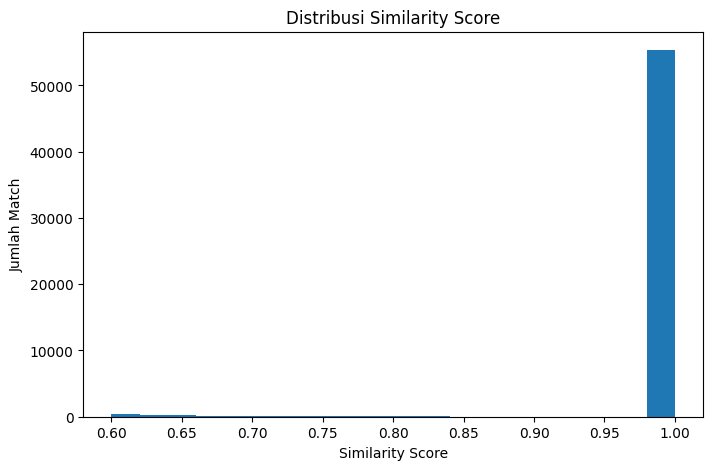

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df_match_final["Similarity"],
    bins=20
)

plt.xlabel("Similarity Score")
plt.ylabel("Jumlah Match")
plt.title("Distribusi Similarity Score")

plt.show()

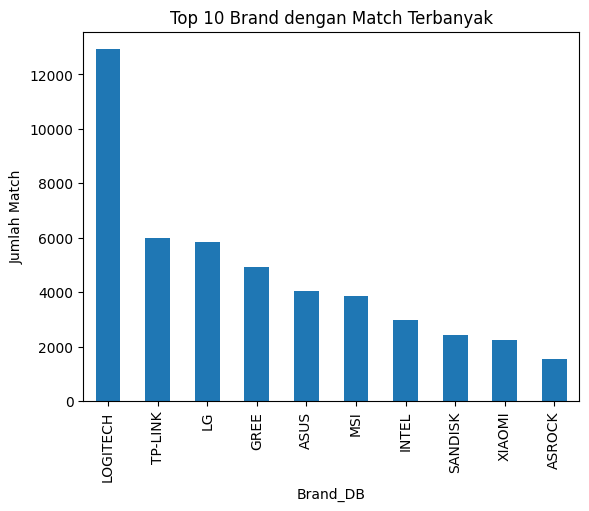

In [49]:
top_brand = (
    df_match_final["Brand_DB"]
    .value_counts()
    .head(10)
)

top_brand.plot(
    kind="bar"
)

plt.title("Top 10 Brand dengan Match Terbanyak")
plt.ylabel("Jumlah Match")

plt.show()

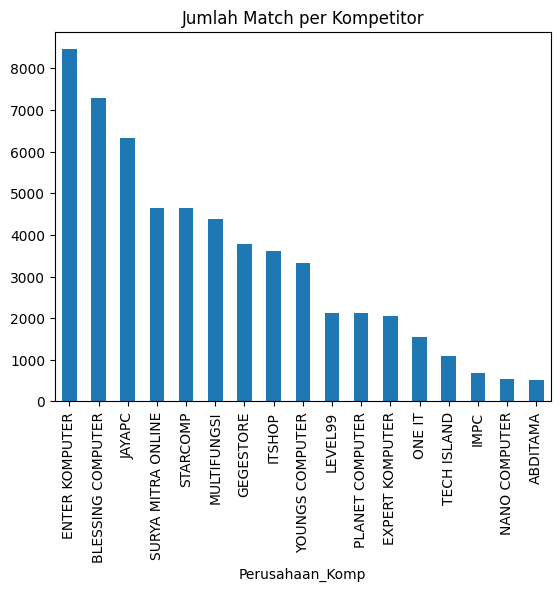

In [50]:
df_match_final["Perusahaan_Komp"]\
    .value_counts()\
    .plot(kind="bar")

plt.title(
    "Jumlah Match per Kompetitor"
)

plt.show()

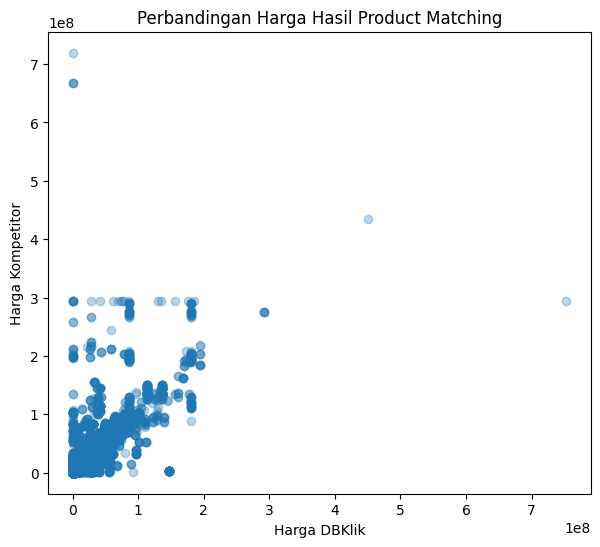

In [51]:
plt.figure(figsize=(7,6))

plt.scatter(
    df_match_final["Harga_DB"],
    df_match_final["Harga_Komp"],
    alpha=0.3
)

plt.xlabel("Harga DBKlik")
plt.ylabel("Harga Kompetitor")

plt.title(
    "Perbandingan Harga Hasil Product Matching"
)

plt.show()

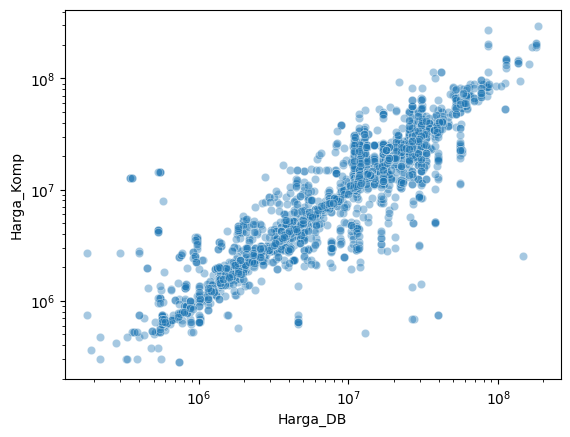

In [52]:
import seaborn as sns

sns.scatterplot(
    data=df_match_final.sample(
        min(3000, len(df_match_final))
    ),
    x="Harga_DB",
    y="Harga_Komp",
    alpha=0.4
)
plt.xscale("log")
plt.yscale("log")

In [53]:
produk_match = df_match_final["Nama_DB"].nunique()

produk_db = df_db["Nama Produk"].nunique()

print("Produk DB unik :", produk_db)
print("Produk match   :", produk_match)

print(
    f"Coverage: {produk_match / produk_db * 100:.2f}%"
)

Produk DB unik : 4355
Produk match   : 1667
Coverage: 38.28%


In [54]:
df_match_final.groupby(
    "Nama_DB"
).size().describe()

,0
count,1667.000000
mean,34.285543
std,81.199923
min,1.000000
25%,4.000000
50%,10.000000
75%,28.000000
max,1116.000000


# cek kolom final

In [55]:
df_match_final.columns.tolist()

['Datetime_DB',
 'Nama_DB',
 'Harga_DB',
 'Qty_DB',
 'Omset_DB',
 'Brand_DB',
 'Main_Model_DB',
 'Specs_DB',
 'Perusahaan_Komp',
 'Datetime_Komp',
 'Nama_Komp',
 'Harga_Komp',
 'Qty_Komp',
 'Omset_Komp',
 'Brand_Komp',
 'Main_Model_Komp',
 'Specs_Komp',
 'Similarity',
 'Method']

In [56]:
df_match_final.head()

,Datetime_DB,Nama_DB,Harga_DB,Qty_DB,Omset_DB,Brand_DB,Main_Model_DB,Specs_DB,Perusahaan_Komp,Datetime_Komp,Nama_Komp,Harga_Komp,Qty_Komp,Omset_Komp,Brand_Komp,Main_Model_Komp,Specs_Komp,Similarity,Method
0,2026-05-12,Sandisk Micro Sd Max Endurance Sdhc 32Gb 100Mb...,2120000.0,2.0,424000.0,SANDISK,GN6IA,32GB,LEVEL99,2026-04-15,Sandisk High Endurance MicroSD Card 32GB Memor...,3900000.0,8.0,3120000.0,SANDISK,GN6IA,32GB,1.0,MODEL_CODE
1,2026-05-12,Sandisk Micro Sd Max Endurance Sdhc 32Gb 100Mb...,2120000.0,2.0,424000.0,SANDISK,GN6IA,32GB,LEVEL99,2026-04-15,SanDisk Max Endurance MicroSD 32GB Class 10 V3...,6100000.0,2.0,1220000.0,SANDISK,GN6IA,32GB,1.0,MODEL_CODE
2,2026-05-12,Sandisk Micro Sd Max Endurance Sdhc 32Gb 100Mb...,2120000.0,2.0,424000.0,SANDISK,GN6IA,32GB,LEVEL99,2026-04-21,Sandisk High Endurance MicroSD Card 32GB Memor...,3900000.0,8.0,3120000.0,SANDISK,GN6IA,32GB,1.0,MODEL_CODE
3,2026-05-12,Sandisk Micro Sd Max Endurance Sdhc 32Gb 100Mb...,2120000.0,2.0,424000.0,SANDISK,GN6IA,32GB,LEVEL99,2026-04-28,Sandisk High Endurance MicroSD Card 32GB Memor...,4100000.0,7.0,2870000.0,SANDISK,GN6IA,32GB,1.0,MODEL_CODE
4,2026-05-12,Sandisk Micro Sd Max Endurance Sdhc 32Gb 100Mb...,2120000.0,2.0,424000.0,SANDISK,GN6IA,32GB,LEVEL99,2026-04-28,SanDisk Max Endurance MicroSD 32GB Class 10 V3...,6100000.0,1.0,610000.0,SANDISK,GN6IA,32GB,1.0,MODEL_CODE


In [57]:
df_db.columns.tolist()

['Datetime',
 'Nama Produk',
 'Harga',
 'Qty',
 'Omset (bln)',
 'Qty (mg)',
 'Omset (mg)',
 'Perusahaan',
 'clean_name',
 'SKU',
 'Kategori',
 'Nama Accurate',
 'Stock Total',
 'HPP (Latest)',
 'Shopee',
 'Kategori Shopee',
 'Margin Harga Shopee (Nilai)',
 'Margin Persen Shopee (%)',
 'SKU_BASE',
 'Margin',
 'Margin_Pct',
 'Brand',
 'Main_Model',
 'Specs']

# feature engineer

In [58]:
# =========================
# FEATURE ENGINEERING
# =========================

agg = df_match_final.groupby(
    [
        "Datetime_DB",
        "Nama_DB",
        "Brand_DB"
    ]
).agg({

    # =====================
    # DBKLIK
    # =====================

    "Harga_DB":"first",

    "Qty_DB":"first",

    "Omset_DB":"first",

    # =====================
    # KOMPETITOR
    # =====================

    "Harga_Komp":[
        "min",
        "mean",
        "max"
    ],

    "Qty_Komp":[
        "mean",
        "max"
    ],

    "Similarity":"mean",

    "Perusahaan_Komp":"nunique"

})

# rapikan nama kolom
agg.columns = [

    "Harga_DB",
    "Qty_DB",
    "Omset_DB",


    "Min_Harga_Komp",
    "Avg_Harga_Komp",
    "Max_Harga_Komp",

    "Avg_Qty_Komp",
    "Max_Qty_Komp",

    "Avg_Similarity",

    "Jumlah_Kompetitor"
]

agg = agg.reset_index()

agg.head()

,Datetime_DB,Nama_DB,Brand_DB,Harga_DB,Qty_DB,Omset_DB,Min_Harga_Komp,Avg_Harga_Komp,Max_Harga_Komp,Avg_Qty_Komp,Max_Qty_Komp,Avg_Similarity,Jumlah_Kompetitor
0,2025-05-19,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,12060000.0,9.0,10854000.0,12899000.0,1.330900e+07,13519000.0,3.333333,6.0,1.0,1
1,2025-05-19,AOC KM170 Keyboard Mouse Wired Combo,AOC,1070000.0,8.0,856000.0,1100000.0,1.100000e+06,1100000.0,1.666667,2.0,1.0,1
2,2025-05-19,ASUS VGA GT710-SL-2GD5-BRK-EVO HDMI D-Sub - VG...,ASUS,8761500.0,1.0,876150.0,8060000.0,8.060000e+06,8060000.0,1.000000,1.0,1.0,1
3,2025-05-19,"ASUS VP227HF LED Monitor 22"" VA FHD 100Hz 1ms ...",ASUS,12094430.0,10.0,12094430.0,11050000.0,1.198833e+07,12586390.0,2.500000,6.0,1.0,3
4,2025-05-19,Acer Emachine Gadget Ac550 Power Supply 550W 8...,ACER,6019200.0,49.0,29494080.0,6708000.0,7.214182e+06,8100000.0,4.272727,8.0,1.0,3


In [59]:
hpp_cols = df_db[
    [
        "Datetime",
        "Nama Produk",
        "HPP (Latest)",
        "Margin",
        "Margin_Pct"
    ]
].drop_duplicates()

agg = agg.merge(
    hpp_cols,
    left_on=["Datetime_DB", "Nama_DB"],
    right_on=["Datetime", "Nama Produk"],
    how="left"
)

In [60]:
# =========================
# PRICE GAP FEATURE
# =========================

agg["Price_Gap_Min"] = (agg["Harga_DB"]-agg["Min_Harga_Komp"])
agg["Price_Gap_Avg"] = (agg["Harga_DB"]-agg["Avg_Harga_Komp"])
agg["Price_Ratio"] = (agg["Harga_DB"]/agg["Avg_Harga_Komp"])

agg["Margin_Rp"] = (agg["Harga_DB"] - agg["HPP (Latest)"])

agg["Margin_Pct"] = (agg["Margin_Rp"] / agg["Harga_DB"]) * 100

agg.head()

,Datetime_DB,Nama_DB,Brand_DB,Harga_DB,Qty_DB,Omset_DB,Min_Harga_Komp,Avg_Harga_Komp,Max_Harga_Komp,Avg_Qty_Komp,...,Jumlah_Kompetitor,Datetime,Nama Produk,HPP (Latest),Margin,Margin_Pct,Price_Gap_Min,Price_Gap_Avg,Price_Ratio,Margin_Rp
0,2025-05-19,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,12060000.0,9.0,10854000.0,12899000.0,1.330900e+07,13519000.0,3.333333,...,1,2025-05-19,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",1025000.0,181000.0,91.500829,-839000.0,-1.249000e+06,0.906154,11035000.0
1,2025-05-19,AOC KM170 Keyboard Mouse Wired Combo,AOC,1070000.0,8.0,856000.0,1100000.0,1.100000e+06,1100000.0,1.666667,...,1,2025-05-19,AOC KM170 Keyboard Mouse Wired Combo,80000.0,27000.0,92.523364,-30000.0,-3.000000e+04,0.972727,990000.0
2,2025-05-19,ASUS VGA GT710-SL-2GD5-BRK-EVO HDMI D-Sub - VG...,ASUS,8761500.0,1.0,876150.0,8060000.0,8.060000e+06,8060000.0,1.000000,...,1,2025-05-19,ASUS VGA GT710-SL-2GD5-BRK-EVO HDMI D-Sub - VG...,495000.0,381150.0,94.350282,701500.0,7.015000e+05,1.087035,8266500.0
3,2025-05-19,"ASUS VP227HF LED Monitor 22"" VA FHD 100Hz 1ms ...",ASUS,12094430.0,10.0,12094430.0,11050000.0,1.198833e+07,12586390.0,2.500000,...,3,2025-05-19,"ASUS VP227HF LED Monitor 22"" VA FHD 100Hz 1ms ...",1077800.0,131643.0,91.088460,1044430.0,1.061008e+05,1.008850,11016630.0
4,2025-05-19,Acer Emachine Gadget Ac550 Power Supply 550W 8...,ACER,6019200.0,49.0,29494080.0,6708000.0,7.214182e+06,8100000.0,4.272727,...,3,2025-05-19,Acer Emachine Gadget Ac550 Power Supply 550W 8...,560500.0,41420.0,90.688131,-688800.0,-1.194982e+06,0.834357,5458700.0


In [61]:
agg.isnull().sum()

,0
Datetime_DB,0
Nama_DB,0
Brand_DB,0
Harga_DB,0
Qty_DB,0
Omset_DB,0
Min_Harga_Komp,0
Avg_Harga_Komp,0
Max_Harga_Komp,0
Avg_Qty_Komp,0


In [62]:
# =========================
# SORT TIME SERIES
# =========================

agg = agg.sort_values(

    by=[
        "Nama_DB",
        "Datetime_DB"
    ]

)

agg.head()

,Datetime_DB,Nama_DB,Brand_DB,Harga_DB,Qty_DB,Omset_DB,Min_Harga_Komp,Avg_Harga_Komp,Max_Harga_Komp,Avg_Qty_Komp,...,Jumlah_Kompetitor,Datetime,Nama Produk,HPP (Latest),Margin,Margin_Pct,Price_Gap_Min,Price_Gap_Avg,Price_Ratio,Margin_Rp
0,2025-05-19,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,12060000.0,9.0,10854000.0,12899000.0,13309000.0,13519000.0,3.333333,...,1,2025-05-19,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",1025000.0,181000.0,91.500829,-839000.0,-1249000.0,0.906154,11035000.0
248,2026-04-15,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11820000.0,99.0,117018000.0,12899000.0,13309000.0,13519000.0,3.333333,...,1,2026-04-15,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",1025000.0,157000.0,91.328257,-1079000.0,-1489000.0,0.888121,10795000.0
499,2026-04-21,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11820000.0,114.0,134748000.0,12899000.0,13309000.0,13519000.0,3.333333,...,1,2026-04-21,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",1025000.0,157000.0,91.328257,-1079000.0,-1489000.0,0.888121,10795000.0
754,2026-04-28,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11467180.0,91.0,104351338.0,12899000.0,13309000.0,13519000.0,3.333333,...,1,2026-04-28,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",1025000.0,121718.0,91.061447,-1431820.0,-1841820.0,0.861611,10442180.0
1175,2026-05-05,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11467180.0,72.0,82563696.0,12899000.0,13309000.0,13519000.0,3.333333,...,1,2026-05-05,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",1025000.0,121718.0,91.061447,-1431820.0,-1841820.0,0.861611,10442180.0


In [63]:
# =========================
# LAG FEATURE
# =========================

# harga sebelumnya
agg["Harga_Lag1"] = (

    agg.groupby("Nama_DB")["Harga_DB"]
    .shift(1)
)

# qty sebelumnya
agg["Qty_Lag1"] = (

    agg.groupby("Nama_DB")["Qty_DB"]
    .shift(1)
)

# avg harga kompetitor sebelumnya
agg["Avg_Harga_Komp_Lag1"] = (

    agg.groupby("Nama_DB")["Avg_Harga_Komp"]
    .shift(1)
)

#margin sebelumnya
agg["Margin_Rp_Lag1"] = (

    agg.groupby("Nama_DB")["Margin_Rp"]
    .shift(1)
)

agg["Margin_Pct_Lag1"] = (

    agg.groupby("Nama_DB")["Margin_Pct"]
    .shift(1)
)

agg.head()

,Datetime_DB,Nama_DB,Brand_DB,Harga_DB,Qty_DB,Omset_DB,Min_Harga_Komp,Avg_Harga_Komp,Max_Harga_Komp,Avg_Qty_Komp,...,Margin_Pct,Price_Gap_Min,Price_Gap_Avg,Price_Ratio,Margin_Rp,Harga_Lag1,Qty_Lag1,Avg_Harga_Komp_Lag1,Margin_Rp_Lag1,Margin_Pct_Lag1
0,2025-05-19,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,12060000.0,9.0,10854000.0,12899000.0,13309000.0,13519000.0,3.333333,...,91.500829,-839000.0,-1249000.0,0.906154,11035000.0,NaN,NaN,NaN,NaN,NaN
248,2026-04-15,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11820000.0,99.0,117018000.0,12899000.0,13309000.0,13519000.0,3.333333,...,91.328257,-1079000.0,-1489000.0,0.888121,10795000.0,12060000.0,9.0,13309000.0,11035000.0,91.500829
499,2026-04-21,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11820000.0,114.0,134748000.0,12899000.0,13309000.0,13519000.0,3.333333,...,91.328257,-1079000.0,-1489000.0,0.888121,10795000.0,11820000.0,99.0,13309000.0,10795000.0,91.328257
754,2026-04-28,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11467180.0,91.0,104351338.0,12899000.0,13309000.0,13519000.0,3.333333,...,91.061447,-1431820.0,-1841820.0,0.861611,10442180.0,11820000.0,114.0,13309000.0,10795000.0,91.328257
1175,2026-05-05,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11467180.0,72.0,82563696.0,12899000.0,13309000.0,13519000.0,3.333333,...,91.061447,-1431820.0,-1841820.0,0.861611,10442180.0,11467180.0,91.0,13309000.0,10442180.0,91.061447


In [64]:
# =========================
# PRICE CHANGE FEATURE
# =========================

import numpy as np

agg["Price_Change"] = (
    agg["Harga_DB"]
    - agg["Harga_Lag1"]
)

agg["Price_Change_Pct"] = np.where(
    agg["Harga_Lag1"] > 0,
    agg["Price_Change"] / agg["Harga_Lag1"],
    np.nan
)

In [65]:
agg[["Harga_DB","Harga_Lag1","Price_Change","Price_Change_Pct", "Margin_Rp", "Margin_Pct"]].head(20)

,Harga_DB,Harga_Lag1,Price_Change,Price_Change_Pct,Margin_Rp,Margin_Pct
0,12060000.0,NaN,NaN,NaN,11035000.0,91.500829
248,11820000.0,12060000.0,-240000.0,-0.019900,10795000.0,91.328257
499,11820000.0,11820000.0,0.0,0.000000,10795000.0,91.328257
754,11467180.0,11820000.0,-352820.0,-0.029849,10442180.0,91.061447
1175,11467180.0,11467180.0,0.0,0.000000,10442180.0,91.061447
2821,12060000.0,11467180.0,592820.0,0.051697,11035000.0,91.500829
249,4010000.0,NaN,NaN,NaN,3810000.0,95.012469
500,4010000.0,4010000.0,0.0,0.000000,3810000.0,95.012469
755,4010000.0,4010000.0,0.0,0.000000,3810000.0,95.012469
1176,4070000.0,4010000.0,60000.0,0.014963,3870000.0,95.085995


In [66]:
# =========================
# ROLLING FEATURE
# =========================

agg["Rolling_Harga_3"] = (

    agg.groupby("Nama_DB")["Harga_DB"]

    .transform(
        lambda x:
        x.rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)

agg["Rolling_Qty_3"] = (

    agg.groupby("Nama_DB")["Qty_DB"]

    .transform(
        lambda x:
        x.rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)

agg.head()

,Datetime_DB,Nama_DB,Brand_DB,Harga_DB,Qty_DB,Omset_DB,Min_Harga_Komp,Avg_Harga_Komp,Max_Harga_Komp,Avg_Qty_Komp,...,Margin_Rp,Harga_Lag1,Qty_Lag1,Avg_Harga_Komp_Lag1,Margin_Rp_Lag1,Margin_Pct_Lag1,Price_Change,Price_Change_Pct,Rolling_Harga_3,Rolling_Qty_3
0,2025-05-19,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,12060000.0,9.0,10854000.0,12899000.0,13309000.0,13519000.0,3.333333,...,11035000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.206000e+07,9.000000
248,2026-04-15,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11820000.0,99.0,117018000.0,12899000.0,13309000.0,13519000.0,3.333333,...,10795000.0,12060000.0,9.0,13309000.0,11035000.0,91.500829,-240000.0,-0.019900,1.194000e+07,54.000000
499,2026-04-21,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11820000.0,114.0,134748000.0,12899000.0,13309000.0,13519000.0,3.333333,...,10795000.0,11820000.0,99.0,13309000.0,10795000.0,91.328257,0.0,0.000000,1.190000e+07,74.000000
754,2026-04-28,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11467180.0,91.0,104351338.0,12899000.0,13309000.0,13519000.0,3.333333,...,10442180.0,11820000.0,114.0,13309000.0,10795000.0,91.328257,-352820.0,-0.029849,1.170239e+07,101.333333
1175,2026-05-05,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11467180.0,72.0,82563696.0,12899000.0,13309000.0,13519000.0,3.333333,...,10442180.0,11467180.0,91.0,13309000.0,10442180.0,91.061447,0.0,0.000000,1.158479e+07,92.333333


In [67]:
# =========================
# DATETIME FEATURE
# =========================

agg["Year"] = (
    agg["Datetime_DB"]
    .dt.year
)

agg["Month"] = (
    agg["Datetime_DB"]
    .dt.month
)

agg["Day"] = (
    agg["Datetime_DB"]
    .dt.day
)

agg["Weekday"] = (
    agg["Datetime_DB"]
    .dt.weekday
)

agg.head()

,Datetime_DB,Nama_DB,Brand_DB,Harga_DB,Qty_DB,Omset_DB,Min_Harga_Komp,Avg_Harga_Komp,Max_Harga_Komp,Avg_Qty_Komp,...,Margin_Rp_Lag1,Margin_Pct_Lag1,Price_Change,Price_Change_Pct,Rolling_Harga_3,Rolling_Qty_3,Year,Month,Day,Weekday
0,2025-05-19,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,12060000.0,9.0,10854000.0,12899000.0,13309000.0,13519000.0,3.333333,...,NaN,NaN,NaN,NaN,1.206000e+07,9.000000,2025,5,19,0
248,2026-04-15,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11820000.0,99.0,117018000.0,12899000.0,13309000.0,13519000.0,3.333333,...,11035000.0,91.500829,-240000.0,-0.019900,1.194000e+07,54.000000,2026,4,15,2
499,2026-04-21,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11820000.0,114.0,134748000.0,12899000.0,13309000.0,13519000.0,3.333333,...,10795000.0,91.328257,0.0,0.000000,1.190000e+07,74.000000,2026,4,21,1
754,2026-04-28,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11467180.0,91.0,104351338.0,12899000.0,13309000.0,13519000.0,3.333333,...,10795000.0,91.328257,-352820.0,-0.029849,1.170239e+07,101.333333,2026,4,28,1
1175,2026-05-05,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11467180.0,72.0,82563696.0,12899000.0,13309000.0,13519000.0,3.333333,...,10442180.0,91.061447,0.0,0.000000,1.158479e+07,92.333333,2026,5,5,1


In [68]:
print(agg["Datetime_DB"].dtype)

datetime64[ns]


In [69]:
print(agg.shape)

agg["Nama_DB"].nunique()

(3194, 35)


1667

In [70]:
#backup
agg_backup = agg.copy()

In [71]:
agg.isna().sum().sort_values(ascending=False).head(20)

,0
Price_Change,1667
Price_Change_Pct,1667
Qty_Lag1,1667
Margin_Rp_Lag1,1667
Avg_Harga_Komp_Lag1,1667
Harga_Lag1,1667
Margin_Pct_Lag1,1667
Brand_DB,0
Nama_DB,0
Datetime_DB,0


In [72]:
# agg = agg.dropna()

agg.shape

(3194, 35)

In [73]:
# =========================
# LOG TARGET
# =========================

import numpy as np

agg["Log_Qty_DB"] = np.log1p(
    agg["Qty_DB"]
)

agg.head()

,Datetime_DB,Nama_DB,Brand_DB,Harga_DB,Qty_DB,Omset_DB,Min_Harga_Komp,Avg_Harga_Komp,Max_Harga_Komp,Avg_Qty_Komp,...,Margin_Pct_Lag1,Price_Change,Price_Change_Pct,Rolling_Harga_3,Rolling_Qty_3,Year,Month,Day,Weekday,Log_Qty_DB
0,2025-05-19,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,12060000.0,9.0,10854000.0,12899000.0,13309000.0,13519000.0,3.333333,...,NaN,NaN,NaN,1.206000e+07,9.000000,2025,5,19,0,2.302585
248,2026-04-15,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11820000.0,99.0,117018000.0,12899000.0,13309000.0,13519000.0,3.333333,...,91.500829,-240000.0,-0.019900,1.194000e+07,54.000000,2026,4,15,2,4.605170
499,2026-04-21,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11820000.0,114.0,134748000.0,12899000.0,13309000.0,13519000.0,3.333333,...,91.328257,0.0,0.000000,1.190000e+07,74.000000,2026,4,21,1,4.744932
754,2026-04-28,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11467180.0,91.0,104351338.0,12899000.0,13309000.0,13519000.0,3.333333,...,91.328257,-352820.0,-0.029849,1.170239e+07,101.333333,2026,4,28,1,4.521789
1175,2026-05-05,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11467180.0,72.0,82563696.0,12899000.0,13309000.0,13519000.0,3.333333,...,91.061447,0.0,0.000000,1.158479e+07,92.333333,2026,5,5,1,4.290459


In [74]:
agg.to_excel("dataset_feature_engineering.xlsx")

In [75]:
agg_model = agg.dropna(
    subset=[
        "Harga_Lag1",
        "Qty_Lag1"
    ]
).copy()

print(agg_model.shape)

(1527, 36)


In [76]:
# =========================
# FEATURE & TARGET
# =========================

# Re-create agg_model from the latest agg DataFrame
# to ensure it includes all recently added features like 'Month', 'Day', 'Weekday', and 'Log_Qty_DB'.
agg_model = agg.dropna(
    subset=[
        "Harga_Lag1",
        "Qty_Lag1"
    ]
).copy()

X = agg_model[[

    "Harga_DB",
    "HPP (Latest)",
    "Margin_Rp",
    "Margin_Pct",

    "Min_Harga_Komp",
    "Avg_Harga_Komp",
    "Max_Harga_Komp",

    "Avg_Qty_Komp",
    "Max_Qty_Komp",

    "Jumlah_Kompetitor",

    # =====================
    # MATCHING
    # =====================

    "Avg_Similarity",

    # =====================
    # PRICE FEATURE
    # =====================

    "Price_Gap_Min",

    "Price_Gap_Avg",

    "Price_Ratio",

    "Price_Change",

    "Price_Change_Pct",

    # =====================
    # TIME SERIES
    # =====================

    "Harga_Lag1",

    "Qty_Lag1",

    "Avg_Harga_Komp_Lag1",

    "Rolling_Harga_3",

    "Rolling_Qty_3",

    # =====================
    # DATETIME
    # =====================

    "Month",

    "Day",

    "Weekday"

]]

# target
y = agg_model["Log_Qty_DB"]

print(X.shape)
print(y.shape)

(1527, 24)
(1527,)


In [77]:
print(X.shape)

X.isna().sum().sort_values(ascending=False).head(20)

(1527, 24)


,0
Harga_DB,0
HPP (Latest),0
Margin_Rp,0
Margin_Pct,0
Min_Harga_Komp,0
Avg_Harga_Komp,0
Max_Harga_Komp,0
Avg_Qty_Komp,0
Max_Qty_Komp,0
Jumlah_Kompetitor,0


In [78]:
# =========================
# TRAIN TEST SPLIT
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1221, 24)
(306, 24)


In [79]:
print(y.describe())

count    1527.000000
mean        1.696737
std         1.248517
min         0.693147
25%         0.693147
50%         1.098612
75%         2.302585
max         6.908755
Name: Log_Qty_DB, dtype: float64


# Random Forest

In [80]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import RandomForestRegressor

# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [10, 20, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# grid = GridSearchCV(
#     RandomForestRegressor(random_state=42),
#     param_grid=param_grid,
#     cv=5,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1
# )

# grid.fit(X_train, y_train)

# print(grid.best_params_)

In [81]:
# =========================
# RANDOM FOREST
# =========================

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(

    n_estimators=100,

    max_depth=10,

    random_state=42,

    n_jobs=-1
)

model.fit(X_train,y_train)

RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

In [82]:
# =========================
# PREDIKSI
# =========================

pred_log = model.predict(X_test)

pred_log[:10]

array([1.09974592, 1.1715325 , 1.77952368, 2.73056514, 2.34318511,
       0.69314718, 0.69314718, 3.61332096, 0.69314718, 0.69314718])

In [83]:
# =========================
# INVERSE LOG
# =========================

pred = np.expm1(pred_log)

y_real = np.expm1(y_test)

pred[:10]

array([ 2.00340281,  2.22693413,  4.92703255, 14.34155463,  9.41435469,
        1.        ,  1.        , 36.08901975,  1.        ,  1.        ])

In [84]:
# =========================
# EVALUASI
# =========================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_real,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_real,
        pred
    )
)

r2 = r2_score(
    y_test,
    pred_log
)

print("MAE :", round(mae,4))
print("RMSE:", round(rmse,4))
print("R2  :", round(r2,4))

MAE : 4.6483
RMSE: 22.6279
R2  : 0.9435


In [85]:
# =========================
# FEATURE IMPORTANCE
# =========================

feat_imp = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        model.feature_importances_

})

feat_imp = feat_imp.sort_values(
    "Importance",
    ascending=False
)

feat_imp.head(20)

,Feature,Importance
20,Rolling_Qty_3,0.912219
17,Qty_Lag1,0.035152
13,Price_Ratio,0.006782
3,Margin_Pct,0.004618
14,Price_Change,0.003480
15,Price_Change_Pct,0.003438
11,Price_Gap_Min,0.003359
1,HPP (Latest),0.003356
9,Jumlah_Kompetitor,0.002608
19,Rolling_Harga_3,0.002573


In [86]:
# =========================
# SAVE MODEL
# =========================

import joblib

joblib.dump(
    model,
    "rf_demand_model.pkl"
)

['rf_demand_model.pkl']

In [87]:
pred_train_log = model.predict(X_train)

pred_train = np.expm1(pred_train_log)

y_train_real = np.expm1(y_train)

In [88]:
from sklearn.metrics import r2_score

print(
    "Train R2:",
    r2_score(
        y_train,
        pred_train_log
    )
)

print(
    "Test R2:",
    r2_score(
        y_test,
        pred_log
    )
)

Train R2: 0.977569342987043
Test R2: 0.9434833803801144


# rf ga pake rolling

In [89]:
X_v2 = X.drop(columns=["Rolling_Qty_3"])

In [90]:
from sklearn.model_selection import train_test_split

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    y,
    test_size=0.2,
    random_state=42
)

In [91]:
from sklearn.ensemble import RandomForestRegressor

model_v2 = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model_v2.fit(
    X_train_v2,
    y_train_v2
)

RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

In [92]:
pred_log_v2 = model_v2.predict(
    X_test_v2
)

In [93]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pred_v2 = np.expm1(pred_log_v2)

y_real_v2 = np.expm1(y_test_v2)

mae_v2 = mean_absolute_error(
    y_real_v2,
    pred_v2
)

rmse_v2 = np.sqrt(
    mean_squared_error(
        y_real_v2,
        pred_v2
    )
)

r2_v2 = r2_score(
    y_test_v2,
    pred_log_v2
)

print("MAE :", mae_v2)
print("RMSE:", rmse_v2)
print("R2  :", r2_v2)

MAE : 7.409552711195686
RMSE: 39.05284808587766
R2  : 0.8617885742376546


In [94]:
feat_imp_v2 = pd.DataFrame({

    "Feature": X_v2.columns,

    "Importance":
        model_v2.feature_importances_

})

feat_imp_v2 = feat_imp_v2.sort_values(
    "Importance",
    ascending=False
)

feat_imp_v2.head(20)

,Feature,Importance
17,Qty_Lag1,0.810515
9,Jumlah_Kompetitor,0.031596
15,Price_Change_Pct,0.016607
13,Price_Ratio,0.014101
11,Price_Gap_Min,0.013410
3,Margin_Pct,0.012466
22,Weekday,0.011514
14,Price_Change,0.010903
10,Avg_Similarity,0.010097
2,Margin_Rp,0.009935


In [96]:
import joblib

joblib.dump(
    model_v2,
    "rf_demand_model_v2.pkl"
)

['rf_demand_model_v2.pkl']

# optimasi harga

In [97]:
agg["Profit"] = (

    agg["Harga_DB"]
    -
    agg["HPP (Latest)"]

) * agg["Qty_DB"]

In [139]:
import numpy as np
# =========================
# OPTIMIZE PRICE
# =========================

def optimize_product(row):

    try:

        harga_awal = row["Harga_DB"]

        hasil_simulasi = []

        # coba harga -20% s/d +20%
        for faktor in np.arange(0.8, 1.21, 0.02):

            harga_baru = harga_awal * faktor

            temp = row.copy()

            # update harga
            temp["Harga_DB"] = harga_baru

            # update feature terkait harga
            temp["Price_Gap_Min"] = (
                harga_baru
                -
                temp["Min_Harga_Komp"]
            )

            temp["Price_Gap_Avg"] = (
                harga_baru
                -
                temp["Avg_Harga_Komp"]
            )

            temp["Price_Ratio"] = (
                harga_baru
                /
                temp["Avg_Harga_Komp"]
            )

            # prediksi demand
            pred_log = model.predict(
                pd.DataFrame(
                    [temp[X.columns]]
                )
            )[0]

            pred_qty = np.expm1(
                pred_log
            )

            # margin
            margin_pct = (

                (
                    harga_baru
                    -
                    temp["HPP (Latest)"]
                )

                /
                harga_baru

            ) * 100

            # profit
            profit = (

                harga_baru
                -
                temp["HPP (Latest)"]

            ) * pred_qty

            hasil_simulasi.append({

                "Harga": harga_baru,

                "Pred_Qty": pred_qty,

                "Margin_Pct": margin_pct,

                "Profit": profit

            })

        hasil_simulasi = pd.DataFrame(
            hasil_simulasi
        )

        # margin minimal 3%
        hasil_simulasi = hasil_simulasi[
            hasil_simulasi["Margin_Pct"] >= 3
        ]

        if len(hasil_simulasi) == 0:

            return pd.Series({

                "Harga_Optimal": np.nan,

                "Pred_Qty_Optimal": np.nan,

                "Profit_Optimal": np.nan
            })

        optimal = hasil_simulasi.loc[
            hasil_simulasi["Profit"].idxmax()
        ]

        profit_optimal = max(
            optimal["Profit"],
            row["Profit"]
        )

        return pd.Series({

            "Harga_Optimal":
                optimal["Harga"],

            "Pred_Qty_Optimal":
                optimal["Pred_Qty"],

            "Profit_Optimal":
                optimal["Profit"]
        })

    except:

        return pd.Series({

            "Harga_Optimal": np.nan,

            "Pred_Qty_Optimal": np.nan,

            "Profit_Optimal": np.nan
        })

In [140]:
test = agg.head(10)

optimasi = test.apply(
    optimize_product,
    axis=1
)

optimasi

,Harga_Optimal,Pred_Qty_Optimal,Profit_Optimal
0,14472000.0,9.077035,1.220589e+08
248,14184000.0,51.927166,6.833096e+08
499,12765600.0,84.628704,9.935918e+08
754,12843241.6,90.066135,1.064423e+09
1175,12843241.6,80.626352,9.528617e+08
2821,14472000.0,23.960537,3.221973e+08
249,4812000.0,1.000000,4.612000e+06
500,4812000.0,1.000000,4.612000e+06
755,4812000.0,1.000000,4.612000e+06
1176,4884000.0,1.000000,4.684000e+06


In [141]:
# =========================
# MERGE RESULT
# =========================

df_optimasi = pd.concat(
    [
        agg.reset_index(drop=True),
        optimasi.reset_index(drop=True)
    ],
    axis=1
)

df_optimasi.head()

,Datetime_DB,Nama_DB,Brand_DB,Harga_DB,Qty_DB,Omset_DB,Min_Harga_Komp,Avg_Harga_Komp,Max_Harga_Komp,Avg_Qty_Komp,...,Rolling_Qty_3,Year,Month,Day,Weekday,Log_Qty_DB,Profit,Harga_Optimal,Pred_Qty_Optimal,Profit_Optimal
0,2025-05-19,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,12060000.0,9.0,10854000.0,12899000.0,13309000.0,13519000.0,3.333333,...,9.000000,2025,5,19,0,2.302585,9.931500e+07,14472000.0,9.077035,1.220589e+08
1,2026-04-15,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11820000.0,99.0,117018000.0,12899000.0,13309000.0,13519000.0,3.333333,...,54.000000,2026,4,15,2,4.605170,1.068705e+09,14184000.0,51.927166,6.833096e+08
2,2026-04-21,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11820000.0,114.0,134748000.0,12899000.0,13309000.0,13519000.0,3.333333,...,74.000000,2026,4,21,1,4.744932,1.230630e+09,12765600.0,84.628704,9.935918e+08
3,2026-04-28,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11467180.0,91.0,104351338.0,12899000.0,13309000.0,13519000.0,3.333333,...,101.333333,2026,4,28,1,4.521789,9.502384e+08,12843241.6,90.066135,1.064423e+09
4,2026-05-05,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11467180.0,72.0,82563696.0,12899000.0,13309000.0,13519000.0,3.333333,...,92.333333,2026,5,5,1,4.290459,7.518370e+08,12843241.6,80.626352,9.528617e+08


In [142]:
df_optimasi[[
    "Harga_DB",
    "HPP (Latest)",
    "Qty_DB",
    "Profit_Optimal",
    "Profit"
]].head()

,Harga_DB,HPP (Latest),Qty_DB,Profit_Optimal,Profit
0,12060000.0,1025000.0,9.0,1.220589e+08,9.931500e+07
1,11820000.0,1025000.0,99.0,6.833096e+08,1.068705e+09
2,11820000.0,1025000.0,114.0,9.935918e+08,1.230630e+09
3,11467180.0,1025000.0,91.0,1.064423e+09,9.502384e+08
4,11467180.0,1025000.0,72.0,9.528617e+08,7.518370e+08


In [143]:
df_optimasi["Profit_Improvement"] = (

    df_optimasi["Profit_Optimal"]

    -

    df_optimasi["Profit"]

)

df_optimasi.head()

,Datetime_DB,Nama_DB,Brand_DB,Harga_DB,Qty_DB,Omset_DB,Min_Harga_Komp,Avg_Harga_Komp,Max_Harga_Komp,Avg_Qty_Komp,...,Year,Month,Day,Weekday,Log_Qty_DB,Profit,Harga_Optimal,Pred_Qty_Optimal,Profit_Optimal,Profit_Improvement
0,2025-05-19,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,12060000.0,9.0,10854000.0,12899000.0,13309000.0,13519000.0,3.333333,...,2025,5,19,0,2.302585,9.931500e+07,14472000.0,9.077035,1.220589e+08,2.274389e+07
1,2026-04-15,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11820000.0,99.0,117018000.0,12899000.0,13309000.0,13519000.0,3.333333,...,2026,4,15,2,4.605170,1.068705e+09,14184000.0,51.927166,6.833096e+08,-3.853954e+08
2,2026-04-21,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11820000.0,114.0,134748000.0,12899000.0,13309000.0,13519000.0,3.333333,...,2026,4,21,1,4.744932,1.230630e+09,12765600.0,84.628704,9.935918e+08,-2.370382e+08
3,2026-04-28,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11467180.0,91.0,104351338.0,12899000.0,13309000.0,13519000.0,3.333333,...,2026,4,28,1,4.521789,9.502384e+08,12843241.6,90.066135,1.064423e+09,1.141850e+08
4,2026-05-05,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",ACER,11467180.0,72.0,82563696.0,12899000.0,13309000.0,13519000.0,3.333333,...,2026,5,5,1,4.290459,7.518370e+08,12843241.6,80.626352,9.528617e+08,2.010248e+08


In [144]:
df_optimasi[[
    "Nama_DB",
    "Harga_DB",
    "Harga_Optimal",
    "Profit",
    "Profit_Optimal",
    "Profit_Improvement"
]].head(10)

,Nama_DB,Harga_DB,Harga_Optimal,Profit,Profit_Optimal,Profit_Improvement
0,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",12060000.0,14472000.0,9.931500e+07,1.220589e+08,2.274389e+07
1,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",11820000.0,14184000.0,1.068705e+09,6.833096e+08,-3.853954e+08
2,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",11820000.0,12765600.0,1.230630e+09,9.935918e+08,-2.370382e+08
3,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",11467180.0,12843241.6,9.502384e+08,1.064423e+09,1.141850e+08
4,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",11467180.0,12843241.6,7.518370e+08,9.528617e+08,2.010248e+08
5,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",12060000.0,14472000.0,1.765600e+08,3.221973e+08,1.456373e+08
6,ACER Router Altos MT401 AX1500 Gigabit Dual Ba...,4010000.0,4812000.0,3.810000e+06,4.612000e+06,8.020000e+05
7,ACER Router Altos MT401 AX1500 Gigabit Dual Ba...,4010000.0,4812000.0,3.810000e+06,4.612000e+06,8.020000e+05
8,ACER Router Altos MT401 AX1500 Gigabit Dual Ba...,4010000.0,4812000.0,3.810000e+06,4.612000e+06,8.020000e+05
9,ACER Router Altos MT401 AX1500 Gigabit Dual Ba...,4070000.0,4884000.0,3.870000e+06,4.684000e+06,8.140000e+05


In [145]:
print(df_optimasi["Profit_Improvement"].describe())

count    1.000000e+01
mean    -1.356227e+07
std      1.757703e+08
min     -3.853954e+08
25%      8.020000e+05
50%      8.080000e+05
75%      9.132469e+07
max      2.010248e+08
Name: Profit_Improvement, dtype: float64


In [146]:
print("Jumlah Produk:",len(df_optimasi))
print("Total Profit Saat Ini:",round(df_optimasi["Profit"].sum(),0))
print("Total Profit Optimal:",round(df_optimasi["Profit_Optimal"].sum(),0))
print("Potensi Kenaikan Profit:",round(df_optimasi["Profit_Improvement"].sum(),0))

Jumlah Produk: 3194
Total Profit Saat Ini: 85175211011.0
Total Profit Optimal: 4156962622.0
Potensi Kenaikan Profit: -135622718.0


In [147]:
df_optimasi.sort_values(by="Profit_Improvement",ascending=False)[[

    "Nama_DB",

    "Harga_DB",

    "Harga_Optimal",

    "Profit",

    "Profit_Optimal",

    "Profit_Improvement"

]].head(20)

,Nama_DB,Harga_DB,Harga_Optimal,Profit,Profit_Optimal,Profit_Improvement
4,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",11467180.0,12843241.6,7.518370e+08,9.528617e+08,2.010248e+08
5,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",12060000.0,14472000.0,1.765600e+08,3.221973e+08,1.456373e+08
3,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",11467180.0,12843241.6,9.502384e+08,1.064423e+09,1.141850e+08
0,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",12060000.0,14472000.0,9.931500e+07,1.220589e+08,2.274389e+07
9,ACER Router Altos MT401 AX1500 Gigabit Dual Ba...,4070000.0,4884000.0,3.870000e+06,4.684000e+06,8.140000e+05
7,ACER Router Altos MT401 AX1500 Gigabit Dual Ba...,4010000.0,4812000.0,3.810000e+06,4.612000e+06,8.020000e+05
8,ACER Router Altos MT401 AX1500 Gigabit Dual Ba...,4010000.0,4812000.0,3.810000e+06,4.612000e+06,8.020000e+05
6,ACER Router Altos MT401 AX1500 Gigabit Dual Ba...,4010000.0,4812000.0,3.810000e+06,4.612000e+06,8.020000e+05
2,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",11820000.0,12765600.0,1.230630e+09,9.935918e+08,-2.370382e+08
1,"ACER LED Monitor SA243Y 24"" IPS FHD 120Hz 1ms ...",11820000.0,14184000.0,1.068705e+09,6.833096e+08,-3.853954e+08


In [148]:
df_optimasi[df_optimasi["Profit_Optimal"]<df_optimasi["Profit"]].shape

(2, 41)

In [149]:
df_optimasi.to_excel("hasil_optimasi_harga.xlsx",index=False)

In [150]:
df_optimasi[
    [
        "Profit",
        "Profit_Optimal",
        "Profit_Improvement"
    ]
].describe()

,Profit,Profit_Optimal,Profit_Improvement
count,3.194000e+03,1.000000e+01,1.000000e+01
mean,2.666725e+07,4.156963e+08,-1.356227e+07
std,7.467565e+07,4.577530e+08,1.757703e+08
min,0.000000e+00,4.612000e+06,-3.853954e+08
25%,0.000000e+00,4.630000e+06,8.020000e+05
50%,4.265000e+06,2.221281e+08,8.080000e+05
75%,2.110350e+07,8.854737e+08,9.132469e+07
max,1.230630e+09,1.064423e+09,2.010248e+08


In [151]:
(df_optimasi["Profit_Optimal"]<df_optimasi["Profit"]).sum()

np.int64(2)

In [152]:
df_optimasi.shape

(3194, 41)

In [153]:
df_optimasi[
    [
        "Profit",
        "Profit_Optimal",
        "Profit_Improvement"
    ]
]

,Profit,Profit_Optimal,Profit_Improvement
0,9.931500e+07,1.220589e+08,2.274389e+07
1,1.068705e+09,6.833096e+08,-3.853954e+08
2,1.230630e+09,9.935918e+08,-2.370382e+08
3,9.502384e+08,1.064423e+09,1.141850e+08
4,7.518370e+08,9.528617e+08,2.010248e+08
...,...,...,...
3189,1.397217e+07,NaN,NaN
3190,1.397217e+07,NaN,NaN
3191,1.417217e+07,NaN,NaN
3192,2.834435e+07,NaN,NaN
